# **Additional Findings: Combined Lags**

**Purpose**
- Examine the combined effect of dengue incidence lag and climate lag variables on dengue risk classification.

**Dataset**
- Processed CALABARZON dengue dataset with climate, socioeconomic, and environmental variables.

**Process**
- Load the prepared dataset.
- Generate lag features for dengue incidence and climate variables.
- Train and evaluate the model using the combined lag features.

**Output**
- Additional findings on model performance using combined dengue incidence and climate lag variables.

In [1]:
# ============================================================
# MODEL: Climate Lag3 + Dengue Incidence Lag1
# Climate + Socioeconomic + Environmental + Lags
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# =============================
# Load Dataset
# =============================
DATA_PATH = "/Users/alexandrasantos/Downloads/Thesis_Dataset_Processed (Final).xlsx"
df = pd.read_excel(DATA_PATH)

Model: Climate Lag3 + Incidence Lag1
Classes: ['High', 'Low', 'Medium']
X shape: (7824, 30)
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV accuracy: 0.8203
Best params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 1200, 'min_child_weight': 6, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.7}

Hold-out accuracy: 0.8339

Classification Report
              precision    recall  f1-score   support

        High       0.64      0.60      0.62        94
         Low       0.88      0.94      0.91      1119
      Medium       0.69      0.56      0.61       352

    accuracy                           0.83      1565
   macro avg       0.74      0.70      0.71      1565
weighted avg       0.82      0.83      0.83      1565



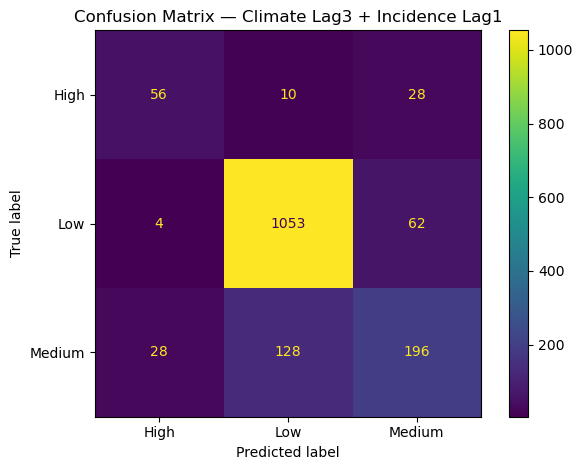

In [3]:
# =============================
# Columns
# =============================

TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain","Temperature","Relative Humidity"]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month","Year"]

GROUP_COL = "Municipality"

INC_COL = "Dengue Incidence"

LEAKAGE_COLS = ["Dengue Cases","Death Cases"]

# =============================
# Clean Dataset
# =============================

df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

df = df.dropna(subset=[TARGET_COL, GROUP_COL, INC_COL, "Month","Year"])

df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

df = df.dropna(subset=["Month","Year"])

df["Month"] = df["Month"].astype(int)
df["Year"] = df["Year"].astype(int)

df = df.sort_values([GROUP_COL,"Year","Month"]).reset_index(drop=True)

# ============================================================
# Create Climate Lag3
# ============================================================

for col in CLIMATE_COLS:
    df[f"{col}_Lag3"] = df.groupby(GROUP_COL)[col].shift(3)

# ============================================================
# Create Incidence Lag1
# ============================================================

df["Incidence_Lag1"] = df.groupby(GROUP_COL)[INC_COL].shift(1)

# Remove rows without lag values
df = df.dropna(subset=[
    "Rain_Lag3",
    "Temperature_Lag3",
    "Relative Humidity_Lag3",
    "Incidence_Lag1"
])

# ============================================================
# Build Dataset
# ============================================================

X = df[
    CLIMATE_COLS +
    SOCIO_COLS +
    ENV_COLS +
    TIME_COLS +
    [
        "Rain_Lag3",
        "Temperature_Lag3",
        "Relative Humidity_Lag3",
        "Incidence_Lag1"
    ]
].copy()

y = df[TARGET_COL].astype(str)

# -----------------------------
# Numeric columns
# -----------------------------

numeric_cols = [
    "Rain","Temperature","Relative Humidity",

    "Rain_Lag3","Temperature_Lag3","Relative Humidity_Lag3",

    "Incidence_Lag1",

    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",

    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",

    "Month","Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# -----------------------------
# Categorical columns
# -----------------------------

cat_cols = ["Municipal Class","Settlement Type","Flood Hazard Level"]

for c in cat_cols:
    X[c] = X[c].astype(str)

X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# -----------------------------
# Encode Target
# -----------------------------

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)

print("Model: Climate Lag3 + Incidence Lag1")
print("Classes:",class_names)
print("X shape:",X.shape)

# ============================================================
# Train/Test Split
# ============================================================

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# ============================================================
# XGBoost + Hyperparameter Tuning
# ============================================================

model = XGBClassifier(
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {

    "n_estimators":[500,800,1200],

    "max_depth":[3,4,5,6,8],

    "learning_rate":[0.03,0.05,0.08,0.1],

    "subsample":[0.7,0.85,1.0],

    "colsample_bytree":[0.7,0.85,1.0],

    "min_child_weight":[1,2,4,6,8],

    "gamma":[0,0.5,1,2],

    "reg_alpha":[0,0.1,0.5,1],

    "reg_lambda":[1,2,5,10]

}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=60,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train,y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:",round(search.best_score_,4))
print("Best params:",search.best_params_)

# ============================================================
# Evaluation
# ============================================================

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test,y_pred)

print("\nHold-out accuracy:",round(acc,4))

print("\nClassification Report")
print(classification_report(y_test,y_pred,target_names=class_names))

cm = confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(cm,display_labels=class_names).plot(values_format="d")

plt.title("Confusion Matrix — Climate Lag3 + Incidence Lag1")

plt.tight_layout()

plt.show()